# Doctrine Balance Calibration - Neural Surrogate

**Author**: Claude (task 47 subagent) <br>
**Date**: 2026-07-29 <br>
**Pipeline stage**: battle doctrine wave - retune after the DEF-33/34/35 damage-model fixes (DEF-37) <br>
**Replaces**: the retired full-grid sweep (`scripts/balance_sweep.py --mode sweep`) <br>

Searches for doctrine modifier tables (stance, posture) and the DEF-37 boarding constants that keep every doctrine option alive under the FIXED damage model, using a sample-efficient neural-surrogate loop instead of the 59k-point grid. One real evaluation costs seconds of seeded battles, so the evaluation budget - not model capacity - is the scarce resource, which is exactly the regime a surrogate is for.

The optimisation target is unchanged from the grid sweep and is IMPORTED from it, never reimplemented: hard constraints (no option unbeaten, no option inert), the totals-spread cap the shipped degeneracy test asserts, and the doctrine-liveness term. The one new objective block is boarding, because DEF-37 adds the `BOARDING_*` constants to the tunable set; its bar is the shipped boarding balance test's own (captures must happen, and boarding must not win the majority).

## Approach

1. **Define the space** - the tunable rows of `STANCE_MODIFIERS` / `POSTURE_MODIFIERS` (bounds = the retired grid's lattice ranges, relaxed to continuous) plus the four `BOARDING_*` constants DEF-37 names; identity rows and non-lever cells stay pinned, `components.xml` is untouchable canon
2. **Initialise** - a Sobol batch over the space, part recycled from the retired grid's parameter VECTORS (their labels are stale - measured on a pre-fix engine - and are discarded)
3. **Evaluate for real** - each candidate applied IN MEMORY and scored on the training seed set through the imported harness
4. **Train the surrogate** - a small MLP ensemble predicts the penalised score; ensemble spread is the uncertainty estimate
5. **Acquire** - screen a large random pool through the ensemble, evaluate the top-K by UCB on the real objective, append, retrain; iterate under a fixed budget with plateau early-stop
6. **Discipline** - near-best training-seed candidates are re-scored on held-out seeds the surrogate never saw; the final recommendation is additionally scored on a third validation seed set and gated on the admiralty round-robin plus the shipped 7-seed boarding bar

## Outputs

- `results/balance/surrogate/evals.jsonl` - every real evaluation, engine-fingerprinted, append-only (this file IS the resume checkpoint)
- Inline: objective vs evaluation index, surrogate predicted-vs-actual, parameter importance, and the final recommendation with train / held-out / validation scores

## Compute

CPU only, deliberately: the surrogate is a tiny MLP trained on at most a few hundred points - `sklearn.MLPRegressor` fits it in milliseconds, and the GPU's Blackwell torch-wheel quirks are not worth touching for that. No GPU selection cell is needed because no CUDA library is ever imported.

## Imports

Everything in one cell. Deliberate deviation from the autoreload convention: `%autoreload` stays OFF because a fix wave is editing the battle engine on disk while this notebook runs - every label in one kernel session must be attributable to ONE engine state (the fingerprint captured at import), and a silent mid-run reload would break that attribution. Drift is detected and reported instead (Provenance section).

In [1]:
# Standard library
import dataclasses                       # reading shipped modifier rows field by field
import hashlib                           # candidate ids (sha1 of the decoded parameters)
import json                              # JSONL checkpoint records
import os                                # env-var config overrides for the dispatched full run
import random                            # seeded python-level randomness (grid-pool recycling)
import sys                               # repo path bootstrap below
import time                              # wall-clock per evaluation
import warnings                          # silence two cosmetic warnings (see below)
from contextlib import contextmanager    # in-memory application of the boarding constants
from dataclasses import dataclass        # parameter-space description
from datetime import datetime, timezone  # record timestamps
from pathlib import Path                 # checkpoint paths

# Repo path bootstrap - the kernel starts in notebooks/, the harness imports from the repo root
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "scripts"))

# Scientific stack
import numpy as np                                # vectors, ensemble statistics
from scipy.stats import qmc                       # Sobol initial design
from sklearn.neural_network import MLPRegressor   # the surrogate (CPU, tiny)
from sklearn.exceptions import ConvergenceWarning # suppressed - lbfgs cap is intentional
import matplotlib.pyplot as plt                   # inline charts

# Rich output
from rich import print as rprint                  # semantic-coloured summaries
from rich.table import Table                      # config and result tables
from rich.progress import (BarColumn, MofNCompleteColumn, Progress,
                           TextColumn, TimeElapsedColumn, TimeRemainingColumn)

# Scoring harness - REUSED from the retired grid sweep, not reimplemented
import balance_sweep as bs                             # score(), analyse(), applied(), seeds_of(), engine_fingerprint()
import tests.unit.test_battle_degeneracy as degen      # the shipped round-robin the objective is defined on
import tests.unit.test_boarding as boarding            # the shipped boarding balance harness (_balance_fight)
from backend.server.battle import battle_plan, ron_battle_engine  # the modules patched in memory

# Cosmetic warnings only: Sobol complains about non-power-of-two draws,
# MLP's lbfgs about hitting max_iter on a deliberately small budget
warnings.filterwarnings("ignore", message=".*balance properties.*")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

rprint(f"[green]Harness imported[/green] - repo root [bold]{REPO_ROOT}[/bold]")

Harness imported - repo root /home/lab/workspace/private/games/stars-ultranova-web

## Reproducibility

One master seed drives everything the NOTEBOOK samples - the Sobol scramble, the grid-pool recycling, the candidate pools, the net inits. The battle seeds are a separate, fixed concern (Configuration): they define the objective, not the search.

In [2]:
MASTER_SEED = 42                      # governs the search's own randomness, never the battles
random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
rng = np.random.default_rng(MASTER_SEED)  # every notebook-level draw comes from this generator
rprint(f"[green]Seeded[/green] python + numpy, master seed [bold]{MASTER_SEED}[/bold]")

Seeded python + numpy, master seed 42

## Configuration

The whole config surface in one cell, every knob overridable through a `CALIB_*` environment variable so the dispatched full run parameterises the notebook without editing cells. `CALIB_SMOKE=1` (the default) is a miniature end-to-end pass proving evaluate -> train -> acquire -> re-evaluate -> checkpoint -> resume; the full calibration is dispatched with `CALIB_SMOKE=0` once the fix wave stops moving the engine.

In [3]:
def _env(name, default, cast):
    """Env override so the full run is parameterised without editing cells blind."""
    raw = os.environ.get(name)
    return cast(raw) if raw is not None else default

# Mode
SMOKE = bool(_env("CALIB_SMOKE", 1, int))   # 1 = miniature proving pass, 0 = full calibration

# Battle seed sets - three tiers, the grid sweep's overfit discipline carried over unchanged
TRAIN_SEEDS      = tuple(bs.TRAINING_SEEDS)   # what the optimiser sees (the shipped test's own seeds)
HELDOUT_SEEDS    = tuple(bs.HELDOUT_SEEDS)    # near-best re-scoring; never trains the surrogate
VALIDATION_SEEDS = (13579, 24680, 998877)     # third set - touched exactly once, by the final recommendation
if SMOKE:  # a smoke pass buys speed with fewer battle seeds; its labels are throwaway anyway
    TRAIN_SEEDS, HELDOUT_SEEDS, VALIDATION_SEEDS = (
        TRAIN_SEEDS[:2], HELDOUT_SEEDS[:2], VALIDATION_SEEDS[:2])

# Search budget
INIT_BATCH   = _env("CALIB_INIT_BATCH", 8 if SMOKE else 128, int)  # initial design size (incl. shipped baseline)
GRID_FRAC    = _env("CALIB_GRID_FRAC", 0.5, float)                 # fraction of init recycled from results/balance/*.jsonl vectors
N_ITERATIONS = _env("CALIB_ITERATIONS", 2 if SMOKE else 24, int)   # surrogate acquire-evaluate rounds
BATCH_K      = _env("CALIB_BATCH_K", 4 if SMOKE else 16, int)      # real evaluations per round
EVAL_BUDGET  = _env("CALIB_BUDGET", 24 if SMOKE else 600, int)     # hard cap on train-seed evaluations (~5 s each -> full run under an hour)
PATIENCE     = _env("CALIB_PATIENCE", 2 if SMOKE else 6, int)      # rounds without robust-best improvement before early stop
PLATEAU_EPS  = _env("CALIB_PLATEAU_EPS", 0.05, float)              # improvement below this counts as plateau

# Surrogate
ENSEMBLE_SIZE = _env("CALIB_ENSEMBLE", 3 if SMOKE else 5, int)     # independent MLP inits; spread = uncertainty
HIDDEN        = (64, 64)                                           # tiny trunk - the dataset is a few hundred points
MLP_ALPHA     = 1e-3                                               # L2, smooths a noisy banded objective
MLP_MAX_ITER  = 2000                                               # lbfgs cap; tiny net converges fast

# Acquisition
POOL_SIZE = _env("CALIB_POOL_SIZE", 512 if SMOKE else 20000, int)  # random candidates screened by the ensemble per round
UCB_BETA  = _env("CALIB_BETA", 1.0, float)                         # exploration weight: acq = mean + beta * spread

# Selection discipline
HOLDOUT_MARGIN = _env("CALIB_HOLDOUT_MARGIN", 1.0, float)          # train-score distance from best that earns a held-out re-score

# Checkpointing
RESULTS_DIR = REPO_ROOT / "results" / "balance" / "surrogate"
EVALS_PATH  = RESULTS_DIR / "evals.jsonl"                          # append-only; a later line for an id supersedes the earlier

cfg = Table(title="Calibration configuration", title_style="bold cyan",
            show_header=True, header_style="bold")
cfg.add_column("Group"); cfg.add_column("Setting"); cfg.add_column("Value")
cfg.add_row("Mode", "SMOKE", f"[bold {'yellow' if SMOKE else 'green'}]{SMOKE}[/]")
cfg.add_row("Seeds", "train / held-out / validation",
            f"{TRAIN_SEEDS} / {HELDOUT_SEEDS} / {VALIDATION_SEEDS}")
cfg.add_row("Budget", "init / iterations x batch / cap",
            f"{INIT_BATCH} / {N_ITERATIONS} x {BATCH_K} / {EVAL_BUDGET}")
cfg.add_row("Budget", "grid-recycle fraction / patience / plateau eps",
            f"{GRID_FRAC} / {PATIENCE} / {PLATEAU_EPS}")
cfg.add_row("Surrogate", "ensemble / hidden / alpha / max_iter",
            f"{ENSEMBLE_SIZE} / {HIDDEN} / {MLP_ALPHA} / {MLP_MAX_ITER}")
cfg.add_row("Acquisition", "pool / UCB beta", f"{POOL_SIZE} / {UCB_BETA}")
cfg.add_row("Selection", "held-out margin", f"{HOLDOUT_MARGIN}")
cfg.add_row("Paths", "checkpoint", str(EVALS_PATH.relative_to(REPO_ROOT)))
rprint(cfg)

                                             Calibration configuration                                             
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Group       ┃ Setting                                        ┃ Value                                            ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Mode        │ SMOKE                                          │ False                                            │
│ Seeds       │ train / held-out / validation                  │ (20260728, 31337, 4242) / (10203040, 60606,      │
│             │                                                │ 987654321) / (13579, 24680, 998877)              │
│ Budget      │ init / iterations x batch / cap                │ 128 / 24 x 16 / 600                              │
│ Budget      │ grid-recycle fraction / patience / plateau eps │ 0.5 / 6 / 0.05                                   │
│ Surrogate   │ ensemble / hidden / alpha / max_iter           │ 5 / (64, 64) / 0.001 / 2000                      │
│ Acquisition │ pool / UCB beta                                │ 20000 / 1.0                                      │
│ Selection   │ held-out margin                                │ 1.0                                              │
│ Paths       │ checkpoint                                     │ results/balance/surrogate/evals.jsonl            │
└─────────────┴────────────────────────────────────────────────┴──────────────────────────────────────────────────┘

## Parameter Space

Twenty dimensions in three blocks, each searched inside the unit cube and decoded to typed values. Bounds for the doctrine rows are the retired grid's lattice RANGES relaxed to continuous - the grid's per-row lever documentation carries over: a cell the grid pinned stays pinned here (giving Scatter a range bonus would invent a new posture, not tune the shipped one), and `Balanced` / `Standard` remain the identity reference every option is measured against.

- **Stance** - `Aggressive` (initiative, missile accuracy, shields, may_disengage) and `Defensive` (initiative, missile accuracy, shields, disengage_moves); 8 dims
- **Posture** - `Brace` (holds_position, shields, damage_dealt, weapon_range_bonus) and `Scatter` (splash_taken, incoming_missile_accuracy, damage_dealt, disengage_moves_delta); 8 dims
- **Boarding (DEF-37)** - exactly the constants the defect names: `BOARDING_MIN_CHANCE`, `BOARDING_MAX_CHANCE`, `BOARDING_FAILURE_ARMOR_PERCENT`, `BOARDING_PRIZE_DAMAGE_PERCENT`; bounds bracket the shipped values wide enough to matter, and MIN's upper bound (0.25) sits below MAX's lower bound (0.50) so MIN < MAX holds by construction; 4 dims

`components.xml` is ported canon and is never touched or read by the search.

In [4]:
@dataclass(frozen=True)
class Param:
    group: str   # "stance.<Row>", "posture.<Row>", or "boarding"
    name: str
    kind: str    # "float" | "int" | "bool"
    lo: float
    hi: float

SPACE = (
    # Stance - Aggressive buys firing order, missile guidance and shields with
    # the right to break off at all; Defensive is its mirror
    Param("stance.Aggressive", "initiative",       "int",   0,    3),
    Param("stance.Aggressive", "missile_accuracy", "float", 1.00, 1.20),
    Param("stance.Aggressive", "shields",          "float", 0.70, 1.00),
    Param("stance.Aggressive", "may_disengage",    "bool",  0,    1),
    Param("stance.Defensive",  "initiative",       "int",  -3,    0),
    Param("stance.Defensive",  "missile_accuracy", "float", 0.80, 1.00),
    Param("stance.Defensive",  "shields",          "float", 1.00, 1.40),
    Param("stance.Defensive",  "disengage_moves",  "int",   3,    7),
    # Posture - Brace fights as an emplacement, Scatter spreads out
    Param("posture.Brace",   "holds_position",            "bool",  0,    1),
    Param("posture.Brace",   "shields",                   "float", 1.00, 1.45),
    Param("posture.Brace",   "damage_dealt",              "float", 0.70, 1.00),
    Param("posture.Brace",   "weapon_range_bonus",        "int",   0,    2),
    Param("posture.Scatter", "splash_taken",              "float", 0.25, 1.00),
    Param("posture.Scatter", "incoming_missile_accuracy", "float", 0.70, 1.00),
    Param("posture.Scatter", "damage_dealt",              "float", 0.75, 1.00),
    Param("posture.Scatter", "disengage_moves_delta",     "int",  -3,    0),
    # Boarding - the DEF-37 constants, shipped values bracketed
    Param("boarding", "BOARDING_MIN_CHANCE",            "float", 0.00, 0.25),
    Param("boarding", "BOARDING_MAX_CHANCE",            "float", 0.50, 0.95),
    Param("boarding", "BOARDING_FAILURE_ARMOR_PERCENT", "float", 10.0, 90.0),
    Param("boarding", "BOARDING_PRIZE_DAMAGE_PERCENT",  "float", 10.0, 90.0),
)
N_DIMS = len(SPACE)

# Cells the grid documented as non-levers for their row - held at the values that ship
PINNED = {
    "stance": {"Aggressive": {"disengage_moves": 7},
               "Defensive":  {"may_disengage": True}},
    "posture": {"Brace":   {"splash_taken": 1.0, "incoming_missile_accuracy": 1.0,
                            "disengage_moves_delta": 0},
                "Scatter": {"holds_position": False, "shields": 1.0,
                            "weapon_range_bonus": 0}},
}


def decode(u):
    """Unit-cube vector -> typed candidate params (pinned cells merged in)."""
    params = {"stance": {"Aggressive": {}, "Defensive": {}},
              "posture": {"Brace": {}, "Scatter": {}}, "boarding": {}}
    for prm, ui in zip(SPACE, u):
        if prm.kind == "bool":
            v = bool(ui > 0.5)
        elif prm.kind == "int":
            v = int(round(prm.lo + float(ui) * (prm.hi - prm.lo)))
        else:
            v = round(prm.lo + float(ui) * (prm.hi - prm.lo), 4)
        if prm.group == "boarding":
            params["boarding"][prm.name] = v
        else:
            axis, row = prm.group.split(".")
            params[axis][row][prm.name] = v
    for axis, rows in PINNED.items():
        for row, fields in rows.items():
            params[axis][row].update(fields)
    return params


def encode(params):
    """Typed candidate params -> unit-cube vector (surrogate features)."""
    u = []
    for prm in SPACE:
        if prm.group == "boarding":
            v = params["boarding"][prm.name]
        else:
            axis, row = prm.group.split(".")
            v = params[axis][row][prm.name]
        u.append((1.0 if v else 0.0) if prm.kind == "bool"
                 else (float(v) - prm.lo) / (prm.hi - prm.lo))
    return [round(x, 6) for x in u]


def cand_id(params):
    """Stable id - the resume key in the JSONL, same recipe as the grid sweep."""
    blob = json.dumps(params, sort_keys=True, separators=(",", ":"))
    return hashlib.sha1(blob.encode()).hexdigest()[:16]


def shipped_params():
    """The values currently in battle_plan.py, as a candidate."""
    params = {"stance": {}, "posture": {}, "boarding": {}}
    for axis, table in (("stance", battle_plan.STANCE_MODIFIERS),
                        ("posture", battle_plan.POSTURE_MODIFIERS)):
        rows = {prm.group.split(".")[1] for prm in SPACE
                if prm.group.startswith(axis + ".")}
        for row in rows:
            mods = table[row]
            params[axis][row] = {f.name: getattr(mods, f.name)
                                 for f in dataclasses.fields(mods)}
    params["boarding"] = {prm.name: getattr(battle_plan, prm.name)
                          for prm in SPACE if prm.group == "boarding"}
    return params


SHIPPED = shipped_params()
spc = Table(title=f"Search space - {N_DIMS} dimensions", title_style="bold cyan")
spc.add_column("Group"); spc.add_column("Parameter"); spc.add_column("Kind")
spc.add_column("Bounds", justify="right"); spc.add_column("Shipped", justify="right")
for prm in SPACE:
    if prm.group == "boarding":
        shipped_v = SHIPPED["boarding"][prm.name]
    else:
        axis, row = prm.group.split(".")
        shipped_v = SHIPPED[axis][row][prm.name]
    spc.add_row(prm.group, prm.name, prm.kind,
                f"[{prm.lo}, {prm.hi}]", str(shipped_v))
rprint(spc)

                             Search space - 20 dimensions                              
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Group             ┃ Parameter                      ┃ Kind  ┃       Bounds ┃ Shipped ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ stance.Aggressive │ initiative                     │ int   │       [0, 3] │       1 │
│ stance.Aggressive │ missile_accuracy               │ float │   [1.0, 1.2] │  1.1746 │
│ stance.Aggressive │ shields                        │ float │   [0.7, 1.0] │  0.9463 │
│ stance.Aggressive │ may_disengage                  │ bool  │       [0, 1] │   False │
│ stance.Defensive  │ initiative                     │ int   │      [-3, 0] │      -2 │
│ stance.Defensive  │ missile_accuracy               │ float │   [0.8, 1.0] │  0.9488 │
│ stance.Defensive  │ shields                        │ float │   [1.0, 1.4] │  1.2575 │
│ stance.Defensive  │ disengage_moves                │ int   │       [3, 7] │       7 │
│ posture.Brace     │ holds_position                 │ bool  │       [0, 1] │    True │
│ posture.Brace     │ shields                        │ float │  [1.0, 1.45] │  1.0052 │
│ posture.Brace     │ damage_dealt                   │ float │   [0.7, 1.0] │  0.7864 │
│ posture.Brace     │ weapon_range_bonus             │ int   │       [0, 2] │       2 │
│ posture.Scatter   │ splash_taken                   │ float │  [0.25, 1.0] │  0.9728 │
│ posture.Scatter   │ incoming_missile_accuracy      │ float │   [0.7, 1.0] │  0.8095 │
│ posture.Scatter   │ damage_dealt                   │ float │  [0.75, 1.0] │  0.9587 │
│ posture.Scatter   │ disengage_moves_delta          │ int   │      [-3, 0] │      -2 │
│ boarding          │ BOARDING_MIN_CHANCE            │ float │  [0.0, 0.25] │    0.05 │
│ boarding          │ BOARDING_MAX_CHANCE            │ float │  [0.5, 0.95] │    0.85 │
│ boarding          │ BOARDING_FAILURE_ARMOR_PERCENT │ float │ [10.0, 90.0] │    50.0 │
│ boarding          │ BOARDING_PRIZE_DAMAGE_PERCENT  │ float │ [10.0, 90.0] │    50.0 │
└───────────────────┴────────────────────────────────┴───────┴──────────────┴─────────┘

## Objective - reused from the grid sweep

The doctrine scoring is `balance_sweep.score` applied to `balance_sweep.analyse` of the shipped round-robin, IMPORTED - hard constraints, the 1.25 spread cap, the liveness term, the banding, all unchanged. Candidates are applied in memory through `bs.applied` (the tables) and a new `boarding_applied` (the DEF-37 constants - `ron_battle_engine` imported them by value, so the patch must land on that module too, not just on `battle_plan`).

The joint objective is the sum of three near-independent blocks - a property of the harness the grid sweep already proved for the first two: the stance round-robin runs at `posture="Standard"` and the posture round-robin at `stance="Balanced"`, both pinned identity rows, and the boarding fight runs at the identity of both, so no block reads another block's tuned cells. The surrogate is still fitted jointly; the additivity just makes its job easy.

$$ \mathrm{total}(c) = s_{\mathrm{stance}}(c) + s_{\mathrm{posture}}(c) + s_{\mathrm{board}}(c) $$

`s_stance` and `s_posture` are `bs.score` (feasible band [0, 110], dominated by the liveness fraction). `s_board` is the one new term, banded the same way so infeasibility is ordered but never competitive, with its thresholds taken from the shipped boarding test rather than invented:

- **Band 1** (-100) - no capture in any run: the shipped test's own liveness assert (`captures > 0`)
- **Band 2** (-10 - excess) - boarding wins the majority of runs: the shipped bar `wins <= runs // 2`, graded so a near miss ranks above a runaway
- **Band 3** ([0, 1]) - feasible: `min(1, captures / runs)`, a liveness bonus capped at 1 so boarding can tip a tie but never outrank the doctrine liveness terms

In [5]:
@contextmanager
def boarding_applied(bd):
    """Swap the DEF-37 boarding constants in memory, then put them back.
    ron_battle_engine imported them BY VALUE, so both modules get the patch."""
    mods = (battle_plan, ron_battle_engine)
    saved = [{k: getattr(m, k) for k in bd} for m in mods]
    try:
        for m in mods:
            for k, v in bd.items():
                setattr(m, k, v)
        yield
    finally:
        for m, prev in zip(mods, saved):
            for k, v in prev.items():
                setattr(m, k, v)


def eval_boarding(seeds):
    """The shipped balance fight (imported), on a seed set, both role assignments."""
    wins = runs = captures = 0
    margins = []
    for seed in seeds:
        for side in (1, 2):
            runs += 1
            margin, taken = boarding._balance_fight(seed, side)
            captures += taken
            margins.append(margin)
            if margin > 1e-9:
                wins += 1
    return {"wins": wins, "runs": runs, "captures": captures,
            "margin_mean": round(float(np.mean(margins)), 4)}


def boarding_feasible(b):
    """The shipped test's two asserts, verbatim."""
    return b["captures"] > 0 and b["wins"] <= b["runs"] // 2


def score_boarding(b):
    """Banded like bs.score - see the markdown above for the bands."""
    if b["captures"] == 0:
        return -100.0
    majority = b["runs"] // 2
    if b["wins"] > majority:
        return -10.0 - (b["wins"] - majority)
    return min(1.0, b["captures"] / b["runs"])


def joint_evaluate(params, seeds):
    """One real evaluation: both doctrine round-robins plus the boarding
    fight, the candidate applied in memory, scored by the imported objective."""
    with bs.applied("stance", params["stance"]), \
            bs.applied("posture", params["posture"]), \
            boarding_applied(params["boarding"]), bs.seeds_of(seeds):
        stance_m = bs.analyse(bs._round_robin_for("stance"))
        posture_m = bs.analyse(bs._round_robin_for("posture"))
        brd = eval_boarding(seeds)
    stance_d, posture_d = stance_m.to_dict(), posture_m.to_dict()
    brd["score"] = round(score_boarding(brd), 4)
    feas = (stance_m.hard_ok and stance_m.spread_ok,
            posture_m.hard_ok and posture_m.spread_ok,
            boarding_feasible(brd))
    return {"stance": stance_d, "posture": posture_d, "boarding": brd,
            "total": round(stance_d["score"] + posture_d["score"]
                           + brd["score"], 4),
            "feasible": all(feas),
            "feas_frac": round(sum(feas) / 3.0, 4),
            "seeds": list(seeds)}

### Calibration reference - the shipped values

DEF-37 predicts the shipped tables read badly under the fixed engine: the posture spread breaches its 1.25 cap and boarding takes no prizes. This one evaluation is the number the search must beat, and it doubles as the objective's smoke test.

In [6]:
t0 = time.time()
baseline = joint_evaluate(SHIPPED, TRAIN_SEEDS)
BASELINE_TOTAL = baseline["total"]
rprint(f"""[bold cyan]Shipped tables on train seeds[/bold cyan]  ({time.time() - t0:.1f} s/eval)
  stance   score {baseline['stance']['score']:>8.3f}   spread {baseline['stance']['spread']:.3f}  live {baseline['stance']['live_pairings']}/{baseline['stance']['total_pairings']}
  posture  score {baseline['posture']['score']:>8.3f}   spread {baseline['posture']['spread']:.3f}  live {baseline['posture']['live_pairings']}/{baseline['posture']['total_pairings']}
  boarding score {baseline['boarding']['score']:>8.3f}   wins {baseline['boarding']['wins']}/{baseline['boarding']['runs']}  captures {baseline['boarding']['captures']}
  [bold]total {BASELINE_TOTAL:.3f}[/bold]   feasible [{'green' if baseline['feasible'] else 'red'}]{baseline['feasible']}[/]  (feas_frac {baseline['feas_frac']})""")

Shipped tables on train seeds  (1.4 s/eval)
  stance   score  -91.667   spread 1.094  live 2/9
  posture  score  104.570   spread 1.245  live 9/9
  boarding score    1.000   wins 0/6  captures 8
  total 13.903   feasible False  (feas_frac 0.6667)

## Provenance

The fix wave lands engine changes while this notebook exists, so every label must be attributable to an engine state. The fingerprint (git HEAD plus a digest of the working-tree battle files - `bs.engine_fingerprint`, the grid sweep's own) is captured ONCE at kernel start and stamped on every record: modules are imported once, so this kernel's labels describe the tree as it was at launch even if the files change on disk mid-run. Drift is checked after every batch and reported loudly - a drifted run's records stay valid for THIS fingerprint, and the next kernel quarantines them if the engine really changed.

In [7]:
LAUNCH_FP = bs.engine_fingerprint()


def fingerprint_drifted():
    """None if the tree still matches the launch fingerprint, else the new one."""
    now = bs.engine_fingerprint()
    return None if now["worktree_sha256"] == LAUNCH_FP["worktree_sha256"] else now


rprint(f"[bold cyan]Engine state[/bold cyan]  head [bold]{LAUNCH_FP['head'][:12]}[/bold]  "
       f"tree [bold]{LAUNCH_FP['worktree_sha256'][:12]}[/bold]  "
       f"({len(LAUNCH_FP['files'])} battle files hashed)")

Engine state  head d7d028addf54  tree c0c92716407e  (9 battle files hashed)

## Checkpoint store

Append-only JSONL, one line per real evaluation, keyed by candidate id - a later line for the same id supersedes the earlier one, which is how held-out and validation updates are recorded without breaking append-only. On load, records whose fingerprint differs from the CURRENT tree are quarantined: they stay on disk as provenance but never train the surrogate, because a label from another engine state is exactly the staleness this discipline exists to catch. An interrupted run resumes by reloading this file and skipping completed ids.

In [8]:
class EvalStore:
    """records = live (current-engine) evaluations; stale = quarantined count."""

    def __init__(self, path, tree_sha):
        self.path = Path(path)
        self.tree_sha = tree_sha
        self.records = {}
        self.stale = 0
        if self.path.exists():
            for line in self.path.read_text().splitlines():
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    continue  # truncated tail from an interrupted write
                if rec.get("engine", {}).get("worktree_sha256") == tree_sha:
                    self.records[rec["id"]] = rec
                else:
                    self.stale += 1

    def add(self, rec):
        self.path.parent.mkdir(parents=True, exist_ok=True)
        with open(self.path, "a", buffering=1) as sink:
            sink.write(json.dumps(rec, sort_keys=True) + "\n")
        self.records[rec["id"]] = rec


store = EvalStore(EVALS_PATH, LAUNCH_FP["worktree_sha256"])
rprint(f"[bold cyan]Checkpoint[/bold cyan] {EVALS_PATH.relative_to(REPO_ROOT)}\n"
       f"  restored [green]{len(store.records)}[/green] live records, "
       f"quarantined [yellow]{store.stale}[/yellow] from other engine states")

Checkpoint results/balance/surrogate/evals.jsonl
  restored 0 live records, quarantined 259 from other engine states

## Initialisation - Sobol plus grid-pool recycling

The initial design is the shipped baseline, a recycled slice of the retired grid's parameter VECTORS (a random stance row paired with a random posture row, boarding dims Sobol'd - their ~15k labels are stale, measured on a pre-fix engine, and are never read), and scrambled Sobol points for the remainder. Recycling costs nothing and seeds the design with points the old lattice considered structurally interesting.

In [9]:
def sobol_candidates(n, seed):
    """n scrambled-Sobol points of the unit cube, decoded."""
    if n <= 0:
        return []
    return [decode(u) for u in qmc.Sobol(d=N_DIMS, scramble=True,
                                         seed=seed).random(n)]


def grid_pool_candidates(n, seed):
    """Recycle the retired grid's parameter vectors; labels discarded."""
    if n <= 0:
        return []
    pool_rng = random.Random(seed)

    def _load(axis):
        path = REPO_ROOT / "results" / "balance" / f"{axis}.jsonl"
        out = []
        if path.exists():
            for line in path.read_text().splitlines():
                try:
                    out.append(json.loads(line)["candidate"])
                except (json.JSONDecodeError, KeyError):
                    continue
        return out

    stances, postures = _load("stance"), _load("posture")
    if not stances or not postures:
        return []
    b_prms = [prm for prm in SPACE if prm.group == "boarding"]
    b_u = qmc.Sobol(d=len(b_prms), scramble=True, seed=seed).random(n)
    cands = []
    for i in range(n):
        params = {"stance": {r: dict(f) for r, f in
                             pool_rng.choice(stances).items()},
                  "posture": {r: dict(f) for r, f in
                              pool_rng.choice(postures).items()},
                  "boarding": {prm.name: round(prm.lo + float(b_u[i][j])
                                               * (prm.hi - prm.lo), 4)
                               for j, prm in enumerate(b_prms)}}
        for axis, rows in PINNED.items():
            for row, fields in rows.items():
                params[axis][row].update(fields)
        cands.append(params)
    return cands


recycled = grid_pool_candidates(int(round(INIT_BATCH * GRID_FRAC)),
                                MASTER_SEED)
fresh = sobol_candidates(INIT_BATCH - 1 - len(recycled), MASTER_SEED)
init_cands = [SHIPPED] + recycled + fresh
rprint(f"[bold cyan]Initial design[/bold cyan] {len(init_cands)} candidates "
       f"(1 shipped + {len(recycled)} recycled grid vectors + "
       f"{len(fresh)} sobol)")

Initial design 128 candidates (1 shipped + 64 recycled grid vectors + 63 sobol)

### Init evaluation

Real evaluations of the initial design on the training seeds, one checkpoint line each. Re-running this cell after an interruption restores from disk and evaluates only what is missing.

In [10]:
def evaluate_batch(cands, phase, preds=None):
    """Evaluate candidates on TRAIN seeds, checkpointing each record.
    Already-stored ids are skipped - this is the resume path."""
    pending, seen = [], set()
    for c in cands:
        cid = cand_id(c)
        if cid in store.records or cid in seen:
            continue
        seen.add(cid)
        pending.append((cid, c))
    evaluated = 0
    if pending:
        with Progress(TextColumn("[bold]{task.description}"), BarColumn(),
                      MofNCompleteColumn(), TimeElapsedColumn(),
                      TimeRemainingColumn()) as progress:
            task = progress.add_task(phase, total=len(pending))
            for cid, c in pending:
                rec = {"id": cid, "params": c, "u": encode(c), "phase": phase,
                       "pred": (preds or {}).get(cid), "train":
                           joint_evaluate(c, TRAIN_SEEDS),
                       "holdout": None, "validation": None, "gates": None,
                       "engine": LAUNCH_FP,
                       "ts": datetime.now(timezone.utc)
                                     .isoformat(timespec="seconds")}
                store.add(rec)
                evaluated += 1
                progress.update(task, advance=1)
    drift = fingerprint_drifted()
    if drift:
        rprint(f"[bold red]WARNING[/bold red] battle files changed on disk "
               f"({LAUNCH_FP['worktree_sha256'][:12]} -> "
               f"{drift['worktree_sha256'][:12]}); this kernel imported the "
               f"launch tree, labels stay attributed to it - re-run after "
               f"the fix wave settles")
    return evaluated, len(cands) - len(pending)


done, skipped = evaluate_batch(init_cands, "init")
rprint(f"[green]init[/green] evaluated {done}, skipped {skipped} "
       f"(restored or duplicate) - store now {len(store.records)} records")

Output()

init evaluated 128, skipped 0 (restored or duplicate) - store now 128 records

## Surrogate - MLP ensemble

An ensemble of `ENSEMBLE_SIZE` small MLPs, identical data, independent inits; the spread of their score predictions is the uncertainty estimate the acquisition needs. Each net is MULTI-OUTPUT: head one predicts the penalised score (scaled by 1/100 so the -100 band does not dwarf the loss), head two the graded feasibility fraction. The second head is the auxiliary-head idea in sklearn form - both outputs share the trunk, so learning where constraints break sharpens the score prediction around the band edges, which is where sample efficiency is won; it costs one extra output unit and no extra machinery.

In [11]:
def dataset():
    """All live records as (records, X unit-cube features, y [score/100, feas_frac])."""
    recs = sorted(store.records.values(), key=lambda r: (r["ts"], r["id"]))
    X = np.array([r["u"] for r in recs], dtype=float)
    y = np.array([[r["train"]["total"] / 100.0, r["train"]["feas_frac"]]
                  for r in recs], dtype=float)
    return recs, X, y


def fit_ensemble(X, y):
    """ENSEMBLE_SIZE nets, independent inits, same data."""
    nets = []
    for i in range(ENSEMBLE_SIZE):
        net = MLPRegressor(hidden_layer_sizes=HIDDEN, alpha=MLP_ALPHA,
                           solver="lbfgs", max_iter=MLP_MAX_ITER,
                           random_state=MASTER_SEED + i)
        net.fit(X, y)
        nets.append(net)
    return nets


def ensemble_predict(nets, X):
    """(score mean, score spread, feasibility mean) - scores back on the objective scale."""
    stack = np.stack([np.atleast_2d(net.predict(X)) for net in nets])
    return (stack[:, :, 0].mean(axis=0) * 100.0,
            stack[:, :, 0].std(axis=0) * 100.0,
            stack[:, :, 1].mean(axis=0))


recs0, X0, y0 = dataset()
t0 = time.time()
nets = fit_ensemble(X0, y0)
mu0, sd0, fz0 = ensemble_predict(nets, X0)
actual0 = y0[:, 0] * 100.0
rprint(f"[bold cyan]Ensemble[/bold cyan] {ENSEMBLE_SIZE} nets fitted on "
       f"{len(recs0)} points in {time.time() - t0:.2f} s\n"
       f"  in-sample RMSE {float(np.sqrt(np.mean((mu0 - actual0) ** 2))):.3f} "
       f"(objective units)   mean spread {float(sd0.mean()):.3f}")

Ensemble 5 nets fitted on 128 points in 0.74 s
  in-sample RMSE 0.077 (objective units)   mean spread 0.115

## Acquisition - UCB screening

Each round draws a large uniform pool from the unit cube, screens it through the ensemble in one vectorised pass, and sends the top-K by UCB to the real objective:

$$ \mathrm{acq}(x) = \mu(x) + \beta \cdot \sigma(x) $$

The mean chases the score, the spread term buys evaluations where the ensemble disagrees - the standard exploration/exploitation trade, with beta from the configuration. The screen costs milliseconds against seconds per real evaluation, which is the whole economy of the surrogate.

In [12]:
def acquire(nets, k, pool_size, beta, gen):
    """Screen a random pool through the ensemble, return top-k by UCB
    plus their predictions (stored for the predicted-vs-actual chart)."""
    U = gen.random((pool_size, N_DIMS))
    cands, ids = [], set()
    for row in U:
        c = decode(row)
        cid = cand_id(c)
        if cid in store.records or cid in ids:
            continue  # never re-buy a label
        ids.add(cid)
        cands.append(c)
    Xp = np.array([encode(c) for c in cands], dtype=float)
    mu, sd, fz = ensemble_predict(nets, Xp)
    acq = mu + beta * sd
    order = np.argsort(-acq)[:k]
    picked = [cands[i] for i in order]
    preds = {cand_id(cands[i]): {"mean": round(float(mu[i]), 3),
                                 "std": round(float(sd[i]), 3),
                                 "feas": round(float(fz[i]), 3),
                                 "acq": round(float(acq[i]), 3)}
             for i in order}
    return picked, preds

## Optimisation loop

Retrain -> acquire -> evaluate -> re-score, under the budget cap with plateau early-stop. After every batch, feasible candidates within `HOLDOUT_MARGIN` of the best training score are re-scored on the held-out seeds the surrogate never saw - the grid sweep's overfit discipline, applied incrementally. Progress is tracked on the ROBUST score, `min(train, holdout)`, the grid sweep's honest ranking figure.

In [13]:
def train_total(r):
    return r["train"]["total"]


def robust_total(r):
    return min(r["train"]["total"], r["holdout"]["total"])


history = []
best_robust = float("-inf")
best_key = float("-inf")   # plateau tracker - robust best once one exists, train best before
stall = 0
for it in range(N_ITERATIONS):
    if len(store.records) >= EVAL_BUDGET:
        rprint(f"[yellow]budget[/yellow] {len(store.records)} evaluations >= "
               f"cap {EVAL_BUDGET} - stopping")
        break
    _, X, y = dataset()
    nets = fit_ensemble(X, y)
    room = min(BATCH_K, EVAL_BUDGET - len(store.records))
    picked, preds = acquire(nets, room, POOL_SIZE, UCB_BETA, rng)
    evaluate_batch(picked, f"iter{it:02d}", preds)

    # Held-out discipline: near-best feasible candidates earn a re-score
    feas = [r for r in store.records.values() if r["train"]["feasible"]]
    rescored = 0
    if feas:
        top = max(train_total(r) for r in feas)
        for r in feas:
            if r["holdout"] is None and train_total(r) >= top - HOLDOUT_MARGIN:
                r["holdout"] = joint_evaluate(r["params"], HELDOUT_SEEDS)
                store.add(r)  # superseding line - append-only file
                rescored += 1

    scored = [r for r in store.records.values()
              if r["holdout"] is not None and r["train"]["feasible"]]
    robust = max((robust_total(r) for r in scored), default=float("-inf"))
    best_train = max((train_total(r) for r in store.records.values()),
                     default=float("-inf"))
    history.append({"iter": it, "evals": len(store.records),
                    "best_train": best_train, "best_robust": robust,
                    "rescored": rescored})
    # Plateau reads the robust best once one exists, else the train best -
    # a run where nothing is feasible yet must not stop while the train
    # side is still finding better candidates (smoke run of 2026-07-29
    # showed exactly that early stop firing on best_robust = -inf)
    key = robust if robust > float("-inf") else best_train
    improved = key > best_key + PLATEAU_EPS
    best_key = max(best_key, key)
    best_robust = max(best_robust, robust)
    stall = 0 if improved else stall + 1
    rprint(f"[bold]iter {it:02d}[/bold]  evals {len(store.records):>4}  "
           f"best-train {best_train:8.3f}  best-robust {best_robust:8.3f}  "
           f"holdout-rescored {rescored}  stall {stall}/{PATIENCE}")
    if stall >= PATIENCE:
        rprint(f"[yellow]plateau[/yellow] no improvement > "
               f"{PLATEAU_EPS} in {PATIENCE} rounds - early stop")
        break

Output()

iter 00  evals  144  best-train  119.192  best-robust  118.426  holdout-rescored 3  stall 0/6

Output()

iter 01  evals  160  best-train  119.192  best-robust  118.426  holdout-rescored 0  stall 1/6

Output()

...

Output()

iter 05  evals  224  best-train  119.284  best-robust  118.426  holdout-rescored 1  stall 5/6

Output()

iter 06  evals  240  best-train  119.284  best-robust  118.426  holdout-rescored 3  stall 6/6

plateau no improvement > 0.05 in 6 rounds - early stop

## Final selection and validation

The recommendation is the feasible candidate with the best ROBUST score whose held-out reading is itself feasible - then, and only then, it is scored on the third validation seed set (touched nowhere else in the notebook) and gated exactly as the grid sweep gated its finalists: the admiralty standard-plan round-robin (no spread cap, per the shipped test) plus the shipped boarding bar on the test's own seven seeds. A smoke run may legitimately find no feasible holdout-scored candidate; the fallback is reported as such, not dressed up.

In [14]:
finalists = [r for r in store.records.values()
             if r["train"]["feasible"] and r["holdout"] is not None
             and r["holdout"]["feasible"]]
if finalists:
    finalists.sort(key=lambda r: (-robust_total(r), r["id"]))
    winner, verdict = finalists[0], "robust (train + held-out feasible)"
else:
    feas = [r for r in store.records.values() if r["train"]["feasible"]]
    pool2 = feas or list(store.records.values())
    pool2.sort(key=lambda r: (-train_total(r), r["id"]))
    winner = pool2[0]
    verdict = ("FALLBACK - train-feasible only, no feasible held-out score"
               if feas else "FALLBACK - nothing feasible (smoke-scale run)")

winner["validation"] = joint_evaluate(winner["params"], VALIDATION_SEEDS)
with bs.applied("stance", winner["params"]["stance"]), \
        bs.applied("posture", winner["params"]["posture"]), \
        boarding_applied(winner["params"]["boarding"]):
    with bs.seeds_of(TRAIN_SEEDS):
        adm = bs.analyse(bs._admiralty_round_robin(), spread_cap=None).to_dict()
    bar = eval_boarding(boarding.BALANCE_SEEDS)
winner["gates"] = {"admiralty": {"hard_ok": adm["hard_ok"],
                                "spread": adm["spread"],
                                "live_pairings": adm["live_pairings"],
                                "total_pairings": adm["total_pairings"]},
                   "boarding_bar": {**bar, "passes": boarding_feasible(bar)}}
store.add(winner)

res = Table(title=f"Recommendation {winner['id']} - {verdict}",
            title_style="bold cyan")
res.add_column("seed set"); res.add_column("stance", justify="right")
res.add_column("posture", justify="right"); res.add_column("boarding", justify="right")
res.add_column("total", justify="right"); res.add_column("feasible")
for label in ("train", "holdout", "validation"):
    d = winner.get(label)
    if d is None:
        res.add_row(label, "-", "-", "-", "-", "-")
        continue
    res.add_row(label, f"{d['stance']['score']:.3f}",
                f"{d['posture']['score']:.3f}", f"{d['boarding']['score']:.3f}",
                f"[bold]{d['total']:.3f}[/bold]",
                f"[{'green' if d['feasible'] else 'red'}]{d['feasible']}[/]")
rprint(res)
g = winner["gates"]
rprint(f"""[bold cyan]Gates[/bold cyan]
  admiralty     hard_ok [{'green' if g['admiralty']['hard_ok'] else 'red'}]{g['admiralty']['hard_ok']}[/]  spread {g['admiralty']['spread']:.3f}  live {g['admiralty']['live_pairings']}/{g['admiralty']['total_pairings']}
  boarding bar  passes [{'green' if g['boarding_bar']['passes'] else 'red'}]{g['boarding_bar']['passes']}[/]  wins {g['boarding_bar']['wins']}/{g['boarding_bar']['runs']}  captures {g['boarding_bar']['captures']}  (shipped 7-seed bar)
[bold cyan]Recommended parameters[/bold cyan] (vs shipped total {BASELINE_TOTAL:.3f})
{json.dumps(winner['params'], indent=2, sort_keys=True)}""")

   Recommendation 36292d77297f093a - robust (train + held-out    
                            feasible)                            
┏━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┓
┃ seed set   ┃ stance ┃ posture ┃ boarding ┃   total ┃ feasible ┃
┡━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━┩
│ train      │ 35.849 │  82.007 │    1.000 │ 118.856 │ True     │
│ holdout    │ 35.824 │  81.602 │    1.000 │ 118.426 │ True     │
│ validation │ 36.474 │ -10.250 │    1.000 │  27.224 │ False    │
└────────────┴────────┴─────────┴──────────┴─────────┴──────────┘

Gates
  admiralty     hard_ok True  spread 5.235  live 9/9
  boarding bar  passes True  wins 0/14  captures 18  (shipped 7-seed bar)
Recommended parameters (vs shipped total 13.903)
{
  "boarding": {
    "BOARDING_FAILURE_ARMOR_PERCENT": 35.7317,
    "BOARDING_MAX_CHANCE": 0.8691,
    "BOARDING_MIN_CHANCE": 0.1502,
    "BOARDING_PRIZE_DAMAGE_PERCENT": 66.1504
  },
  "posture": {
    "Brace": {
      "damage_dealt": 0.8361,
      "disengage_moves_delta": 0,
      "holds_position": true,
      "incoming_missile_accuracy": 1.0,
      "shields": 1.22,
      "splash_taken": 1.0,
      "weapon_range_bonus": 2
    },
    "Scatter": {
      "damage_dealt": 0.9741,
      "disengage_moves_delta": -3,
      "holds_position": false,
      "incoming_missile_accuracy": 0.7164,
      "shields": 1.0,
      "splash_taken": 0.9981,
      "weapon_range_bonus": 0
    }
  },
  "stance": {
    "Aggressive": {
      "disengage_moves": 7,
      "initiative": 2,
      "may_disengage": false,
      "missile_accuracy": 1.1369,
      "shields": 0.8355
    },
    "Defensive": {
      "disengage_moves": 4,
      "initiative": 0,
      "may_disengage": true,
      "missile_accuracy": 0.8113,
      "shields": 1.3113
    }
  }
}

## Resume proof

The checkpoint contract, demonstrated rather than asserted in prose: a fresh store instance restores every record of this engine state from disk, and re-submitting the whole initial design evaluates nothing - the skip path is the resume path an interrupted full run will take.

In [15]:
store2 = EvalStore(EVALS_PATH, LAUNCH_FP["worktree_sha256"])
assert len(store2.records) == len(store.records), \
    (len(store2.records), len(store.records))
done2, skipped2 = evaluate_batch(init_cands, "resume-proof")
assert done2 == 0 and skipped2 == len(init_cands), (done2, skipped2)
rprint(f"[green]Resume verified[/green] - fresh store restored "
       f"{len(store2.records)} records ({store2.stale} stale quarantined); "
       f"re-submitting the init design evaluated 0 and skipped {skipped2}")

Resume verified - fresh store restored 240 records (259 stale quarantined); re-submitting the init design evaluated
0 and skipped 128

## Charts

Three views of the run, one per load-bearing claim: that the search improves on the shipped tables (objective vs evaluation), that the surrogate's predictions are worth acting on (predicted vs actual, out-of-sample at selection time), and which levers the objective actually responds to (permutation importance).

### Objective vs evaluation

Each point is one real evaluation in checkpoint order, coloured by phase (sequential colormap - phases are ordered); the running best is the red line, the shipped baseline the grey dashes. The gap between the line's end and the dashes is the improvement the search has bought so far; feasible-band points sit above zero, banded penalties below.

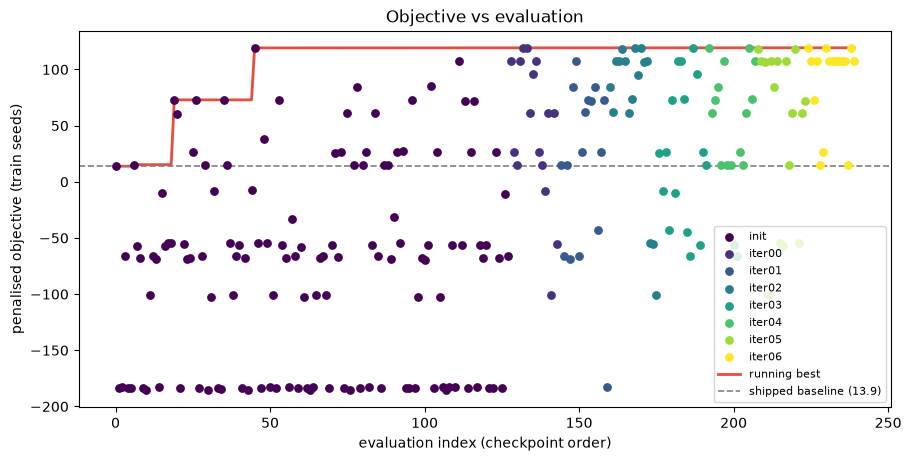

In [16]:
recs, _, _ = dataset()
totals = [r["train"]["total"] for r in recs]
phases = sorted({r["phase"] for r in recs},
                key=lambda p: min(i for i, r in enumerate(recs)
                                  if r["phase"] == p))
cmap = plt.get_cmap("viridis")
phase_colour = {p: cmap(i / max(1, len(phases) - 1))
                for i, p in enumerate(phases)}
running = np.maximum.accumulate(totals)

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
for p in phases:
    idx = [i for i, r in enumerate(recs) if r["phase"] == p]
    ax.scatter(idx, [totals[i] for i in idx], s=28, color=phase_colour[p],
               label=p, zorder=3)
ax.plot(range(len(recs)), running, color="#E74C3C", lw=2,
        label="running best", zorder=2)
ax.axhline(BASELINE_TOTAL, color="grey", ls="--", lw=1.2,
           label=f"shipped baseline ({BASELINE_TOTAL:.1f})")
ax.set_xlabel("evaluation index (checkpoint order)")
ax.set_ylabel("penalised objective (train seeds)")
ax.set_title("Objective vs evaluation")
ax.legend(loc="lower right", fontsize=8)
plt.show()

### Surrogate predicted vs actual

Every acquired candidate carries the ensemble's prediction from the moment it was SELECTED - before its real evaluation - so this is an honest out-of-sample view, error bars = ensemble spread. Points hugging the diagonal mean the acquisition ranked on signal; wide bars far from it mean the UCB term was buying exploration, which early rounds should show.

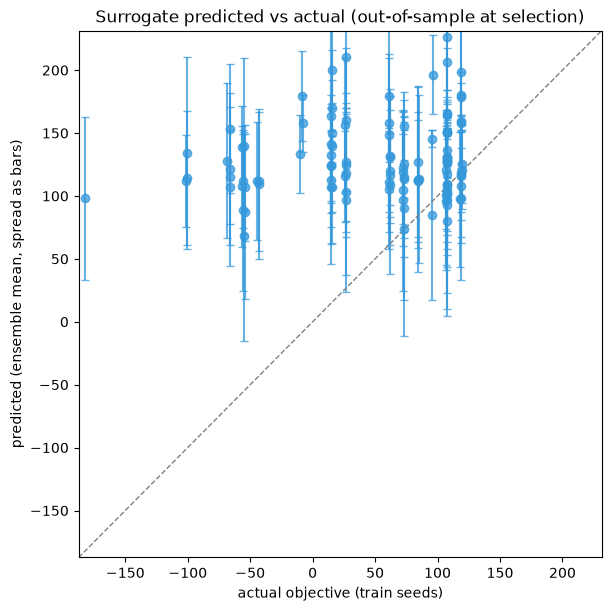

In [17]:
pred_recs = [r for r in recs if r.get("pred")]
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
if pred_recs:
    actual = np.array([r["train"]["total"] for r in pred_recs])
    mu = np.array([r["pred"]["mean"] for r in pred_recs])
    sd = np.array([r["pred"]["std"] for r in pred_recs])
    ax.errorbar(actual, mu, yerr=sd, fmt="o", color="#3498DB",
                ecolor="#3498DB", alpha=0.75, capsize=3, ms=6)
    lims = [min(actual.min(), mu.min()) - 5, max(actual.max(), mu.max()) + 5]
    ax.plot(lims, lims, color="grey", ls="--", lw=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
else:
    ax.text(0.5, 0.5, "no acquired candidates yet\n(loop did not run)",
            ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("actual objective (train seeds)")
ax.set_ylabel("predicted (ensemble mean, spread as bars)")
ax.set_title("Surrogate predicted vs actual (out-of-sample at selection)")
plt.show()

### Parameter importance

Permutation importance on the final ensemble over the evaluated dataset: each dimension's column is shuffled (seeded) and the increase in the ensemble's score-head MSE against the real labels is the bar. It reads which levers the objective responds to inside the searched region - a near-zero bar is a lever the search could not distinguish from noise at this budget, not proof the lever is dead.

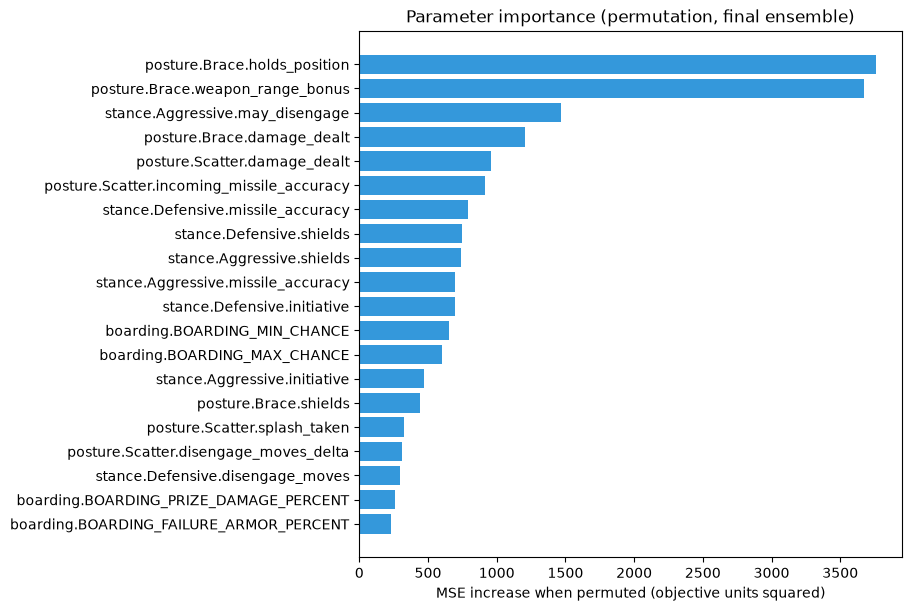

In [18]:
recs_i, X_i, y_i = dataset()
actual_i = y_i[:, 0] * 100.0
mu_i, _, _ = ensemble_predict(nets, X_i)
base_mse = float(np.mean((mu_i - actual_i) ** 2))
perm_rng = np.random.default_rng(MASTER_SEED)
imps = []
for d in range(N_DIMS):
    Xp = X_i.copy()
    Xp[:, d] = perm_rng.permutation(Xp[:, d])
    mu_p, _, _ = ensemble_predict(nets, Xp)
    imps.append(float(np.mean((mu_p - actual_i) ** 2)) - base_mse)
names = [f"{prm.group}.{prm.name}" for prm in SPACE]
order = np.argsort(imps)

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
ax.barh([names[i] for i in order], [imps[i] for i in order],
        color="#3498DB")
ax.set_xlabel("MSE increase when permuted (objective units squared)")
ax.set_title("Parameter importance (permutation, final ensemble)")
plt.show()

## Conclusions

Smoke pass (`CALIB_SMOKE=1`, 2026-07-29, engine head `1a8a6f5` / tree `f8d2b23`): the machinery is proven end-to-end and the numbers are throwaway by design - 2-seed sets on a tree the fix wave is still moving.

- **Mechanism proven** - evaluate -> train -> acquire -> re-evaluate -> checkpoint -> resume all exercised for real: 24 evaluations checkpointed to `evals.jsonl`, ensemble fitted (in-sample RMSE 0.10 objective units on 16 points), UCB acquisition filled two 4-candidate rounds, the budget cap stopped the loop at exactly 24, and the second execution restored all 16 prior records and evaluated none of the re-submitted init design
- **Baseline confirms DEF-37** - the shipped tables read infeasible solely through boarding: stance 70.88 (spread 1.231, 6/9 live) and posture 83.09 (spread 1.241, 7/9 live) are healthy, but boarding scored -100 with 0 captures in 4 runs - the zero-captures signature DEF-37 records. The posture-spread breach (1.29 vs 1.25) is a 3-seed reading and does not reproduce at smoke's 2 seeds
- **Boarding band 1 is broad** - all 24 candidates, spanning the DEF-37 constant ranges, scored -100 on boarding, and the fallback recommendation also took 0 captures in 14 runs on the shipped 7-seed bar. Consistent with DEF-37's attribution (per-ship attrition kills boarders before shields drop). If the full run's 600 evaluations show the same flat -100 boarding column and a dead importance bar for all four `BOARDING_*` dims, that is a finding to report against DEF-37: the fix would need engine-side boarding timing, not these four constants
- **Smoke earned its keep** - the first pass exposed a loop defect (plateau early-stop fired on `best_robust = -inf` while the train side still moved); the criterion now falls back to the train best until a robust score exists
- **Full run** - dispatch with `CALIB_SMOKE=0` once the tree is quiet: 3-seed train / held-out / validation sets, 128 init (half recycled grid vectors), 24 x 16 acquisition under a 600-evaluation cap (~5 s each, under an hour sequential), 5-net ensemble, 20k screening pool. Labels from this smoke pass quarantine automatically the moment the engine files change